In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [3]:
import pandas as pd

df = pd.read_csv("hotel_bookings.csv")

print(df.head())
print(df.shape)
print(df.columns)

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [4]:
df.isnull().sum

<bound method DataFrame.sum of         hotel  is_canceled  lead_time  arrival_date_year  arrival_date_month  \
0       False        False      False              False               False   
1       False        False      False              False               False   
2       False        False      False              False               False   
3       False        False      False              False               False   
4       False        False      False              False               False   
...       ...          ...        ...                ...                 ...   
119385  False        False      False              False               False   
119386  False        False      False              False               False   
119387  False        False      False              False               False   
119388  False        False      False              False               False   
119389  False        False      False              False               False   

        

In [5]:
print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (87396, 32)


In [7]:
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)

In [8]:
df = df[df["adults"] + df["children"] + df["babies"] > 0]

df = df[df["adr"] >= 0]

In [9]:
df["total_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

In [10]:
df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

In [11]:
df["room_changed"] = (
    df["reserved_room_type"] != df["assigned_room_type"]
).astype(int)

In [12]:
y = df["is_canceled"]

In [13]:
features = [
    "lead_time",
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "assigned_room_type",
    "booking_changes",
    "deposit_type",
    "agent",
    "company",
    "days_in_waiting_list",
    "customer_type",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "total_nights",
    "total_guests",
    "room_changed"
]

X = df[features]
y = df["is_canceled"]

In [14]:
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", X.shape)

Features after encoding: (87229, 248)


In [15]:
X = X.astype(int)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (69783, 248)
Testing data: (17446, 248)


In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
model = Sequential()

model.add(Dense(128, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))

model.add(Dense(1, activation="sigmoid"))

c:\Users\Dipendra Yadav\Desktop\ANN-Hotel_booking\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,241 (165.00 KB)

 Trainable params: 42,241 (165.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7905 - loss: 0.4403 - val_accuracy: 0.8060 - val_loss: 0.4042
Epoch 2/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8108 - loss: 0.3947 - val_accuracy: 0.8083 - val_loss: 0.3885
Epoch 3/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8167 - loss: 0.3824 - val_accuracy: 0.8135 - val_loss: 0.3854
Epoch 4/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8219 - loss: 0.3754 - val_accuracy: 0.8202 - val_loss: 0.3792
Epoch 5/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8242 - loss: 0.3698 - val_accuracy: 0.8211 - val_loss: 0.3735
Epoch 6/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8283 - loss: 0.3635 - val_accuracy: 0.8207 - val_loss: 0.3758
Epoch 7/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8296 - loss: 0.3600 - val_accuracy: 0.8270 - val_loss: 0.3700
Epoch 8/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8317 - loss: 0.3565 -

In [22]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8405 - loss: 0.3457
Test Loss: 0.3457365334033966
Test Accuracy: 0.8404791951179504


In [23]:
y_probability = model.predict(X_test)

y_pred = (y_probability >= 0.5).astype(int)

546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8404791929382094


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.89     12644
           1       0.72      0.69      0.71      4802

    accuracy                           0.84     17446
   macro avg       0.80      0.80      0.80     17446
weighted avg       0.84      0.84      0.84     17446



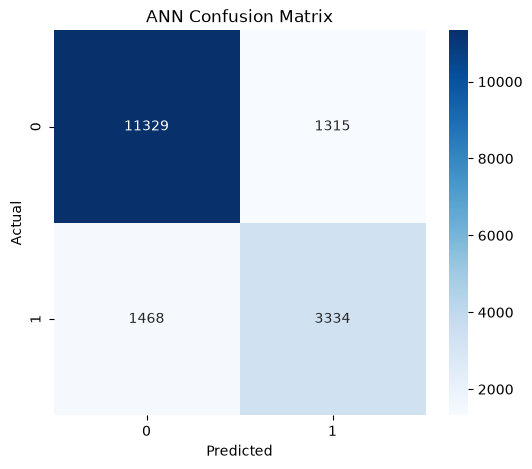

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")
plt.show()

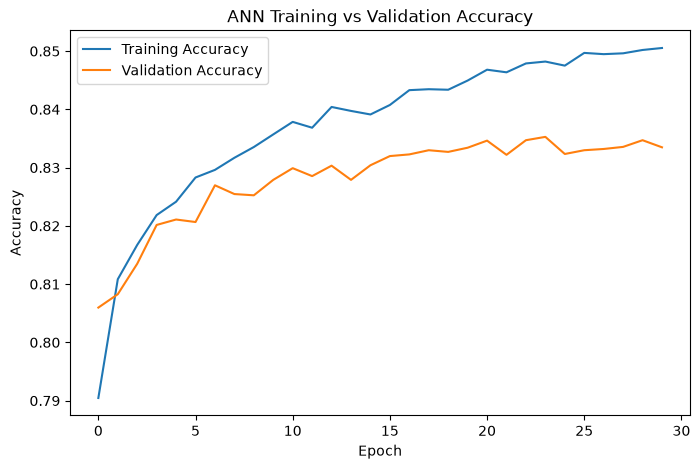

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Training vs Validation Accuracy")
plt.legend()
plt.show()

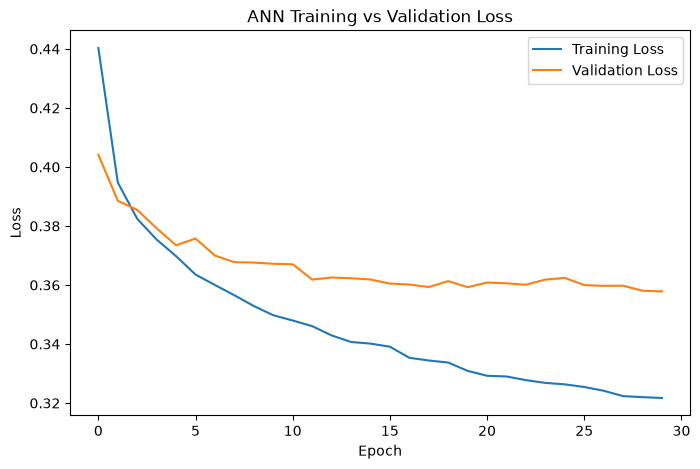

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training vs Validation Loss")
plt.legend()
plt.show()

In [29]:
model.save("hotel_booking_ann_model.keras")

In [30]:
import joblib

joblib.dump(scaler, "hotel_booking_scaler.pkl")

['hotel_booking_scaler.pkl']

In [31]:
import os

print(os.path.exists("hotel_booking_ann_model.keras"))
print(os.path.exists("hotel_booking_scaler.pkl"))

True
True


In [32]:
# Save feature column names
feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    "hotel_booking_feature_columns.pkl"
)

print("Feature columns saved successfully!")
print("Total features:", len(feature_columns))

Feature columns saved successfully!
Total features: 248


In [33]:
import os

print(
    os.path.exists("hotel_booking_ann_model.keras")
)

print(
    os.path.exists("hotel_booking_scaler.pkl")
)

print(
    os.path.exists("hotel_booking_feature_columns.pkl")
)

True
True
True


In [34]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# Load trained ANN model
model = load_model("hotel_booking_ann_model.keras")

# Load scaler
scaler = joblib.load("hotel_booking_scaler.pkl")

# Load feature columns
feature_columns = joblib.load("hotel_booking_feature_columns.pkl")

print("Model loaded successfully!")
print("Scaler loaded successfully!")
print("Feature columns loaded successfully!")
print("Total features:", len(feature_columns))

Model loaded successfully!
Scaler loaded successfully!
Feature columns loaded successfully!
Total features: 248


In [35]:
new_booking = pd.DataFrame([{
    "lead_time": 50,
    "arrival_date_year": 2017,
    "arrival_date_month": "July",
    "arrival_date_week_number": 28,
    "arrival_date_day_of_month": 15,
    "stays_in_weekend_nights": 1,
    "stays_in_week_nights": 3,
    "adults": 2,
    "children": 0,
    "babies": 0,
    "meal": "BB",
    "country": "PRT",
    "market_segment": "Online TA",
    "distribution_channel": "TA/TO",
    "is_repeated_guest": 0,
    "previous_cancellations": 0,
    "previous_bookings_not_canceled": 0,
    "reserved_room_type": "A",
    "assigned_room_type": "A",
    "booking_changes": 0,
    "deposit_type": "No Deposit",
    "agent": 9,
    "company": 0,
    "days_in_waiting_list": 0,
    "customer_type": "Transient",
    "adr": 100,
    "required_car_parking_spaces": 0,
    "total_of_special_requests": 1,
    "total_nights": 4,
    "total_guests": 2,
    "room_changed": 0
}])

print(new_booking)

   lead_time  arrival_date_year arrival_date_month  arrival_date_week_number  \
0         50               2017               July                        28   

   arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights  \
0                         15                        1                     3   

   adults  children  babies  ... agent company days_in_waiting_list  \
0       2         0       0  ...     9       0                    0   

  customer_type  adr  required_car_parking_spaces  total_of_special_requests  \
0     Transient  100                            0                          1   

  total_nights total_guests  room_changed  
0            4            2             0  

[1 rows x 31 columns]


In [36]:
# Convert categorical columns into dummy variables
new_booking_encoded = pd.get_dummies(
    new_booking,
    drop_first=True
)

# Make sure new booking has exactly the same columns
new_booking_encoded = new_booking_encoded.reindex(
    columns=feature_columns,
    fill_value=0
)

# Convert to integer
new_booking_encoded = new_booking_encoded.astype(int)

print("Encoded shape:", new_booking_encoded.shape)

Encoded shape: (1, 248)


In [37]:
# Scale the new booking using the same scaler
new_booking_scaled = scaler.transform(new_booking_encoded)

print("Booking scaled successfully!")
print("Shape:", new_booking_scaled.shape)

Booking scaled successfully!
Shape: (1, 248)


In [38]:
# Predict cancellation probability
probability = model.predict(new_booking_scaled)[0][0]

# Convert probability into percentage
probability_percent = probability * 100

# Prediction
if probability >= 0.5:
    prediction = "CANCELLED"
else:
    prediction = "NOT CANCELLED"

print("--------------------------------")
print("HOTEL BOOKING PREDICTION")
print("--------------------------------")
print(f"Cancellation Probability: {probability_percent:.2f}%")
print(f"Prediction: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
--------------------------------
HOTEL BOOKING PREDICTION
--------------------------------
Cancellation Probability: 62.90%
Prediction: CANCELLED
